# 📊 Regresi Linier (Linear Regression)

## 1. Apa itu Regresi Linier?

Regresi Linier adalah metode **supervised learning** untuk memprediksi nilai **kontinu** (bukan kategori). Dalam peta machine learning, posisinya adalah:

```{list-table} Peta Machine Learning
:header-rows: 1
:widths: 25 35 35

* -
  - Kontinu
  - Kategorikal
* - **Supervised**
  - **Regression** ✅ ← kita di sini
  - Classification
* - **Unsupervised**
  - Dimension Reduction
  - Clustering
```

:::{admonition} Mengapa Regresi Linier penting dipelajari?
:class: tip

- **Widely used** — banyak digunakan di industri dan akademik
- **Runs fast** — komputasi sangat cepat
- **Easy to use** — tidak perlu banyak hyperparameter tuning
- **Highly interpretable** — koefisien mudah dijelaskan secara intuitif
- **Basis for many methods** — fondasi Ridge, Lasso, Logistic Regression, dsb.
:::

---

## 2. Model Regresi Linier Sederhana

Persamaan dasar regresi linier sederhana (satu prediktor):

$$y = b_0 + b_1 x + \varepsilon$$

```{list-table} Komponen Model
:header-rows: 1
:widths: 15 25 60

* - Simbol
  - Nama
  - Keterangan
* - $y$
  - Response variable
  - Nilai yang ingin diprediksi (target)
* - $x$
  - Input variable
  - Variabel prediktor / fitur
* - $b_0$
  - Intercept
  - Titik potong garis dengan sumbu-$y$
* - $b_1$
  - Regression coefficient
  - Kemiringan garis $\left(\dfrac{\Delta y}{\Delta x}\right)$
* - $\varepsilon$
  - Residual
  - Error — selisih nilai prediksi dengan data asli
```

---

## 3. Model Regresi Linier Berganda (Multiple)

Diperluas untuk beberapa variabel input sekaligus:

$$y = b_0 + b_1 x_1 + b_2 x_2 + \cdots + b_n x_n + \varepsilon$$

Dalam notasi matriks yang lebih ringkas:

$$\mathbf{y} = X\mathbf{b} + \boldsymbol{\varepsilon}$$

di mana $X \in \mathbb{R}^{n \times (p+1)}$ adalah matriks fitur yang sudah ditambah kolom 1 (bias).

---

## 4. Estimasi Koefisien — Ordinary Least Squares (OLS)

### Konsep: Meminimalkan Sum of Squared Residuals

Kita mencari garis $\hat{y}$ yang **meminimalkan** jumlah kuadrat error:

$$SS_{\text{residuals}} = \sum_{i=1}^{N} \left(\hat{y}_i - y_i\right)^2$$

:::{note}
Mengapa *dikuadratkan*? Agar nilai positif dan negatif tidak saling menghilangkan, dan memberikan penalti lebih besar untuk error yang besar.
:::

### Solusi Analitik OLS

Melalui kalkulus (meminimalkan $SS_{res}$ terhadap $\mathbf{b}$), diperoleh formula tertutup:

```{math}
:label: eq-ols
\boxed{\hat{\mathbf{b}} = \left(X^T X\right)^{-1} X^T Y}
```

**Keterangan:**

| Term | Peran |
|------|-------|
| $X$ | Matriks fitur (kolom pertama = 1 untuk intercept) |
| $Y$ | Vektor target/response |
| $X^T$ | Transpose matriks $X$ (baris ↔ kolom) |
| $(X^TX)^{-1}$ | Invers matriks — hanya bisa dihitung jika $X^TX$ *invertible* |

Lihat persamaan {eq}`eq-ols` — ini adalah formula utama yang kita implementasikan di Python maupun GeoGebra.

---

## 5. Contoh Perhitungan Manual

### Dataset

```{list-table} Data 7 Titik Observasi
:header-rows: 1
:widths: 20 40 40

* - Titik
  - $X$ (Variabel Input)
  - $Y$ (Variabel Respon)
* - A
  - 2
  - 2
* - B
  - 4
  - 3
* - C
  - 5
  - 5
* - D
  - 3
  - 4
* - E
  - 3
  - 3
* - F
  - 4
  - 5
* - G
  - 5
  - 6
```

**Statistik dasar:**

$$\bar{x} = \frac{2+4+5+3+3+4+5}{7} = \frac{26}{7} \approx 3.714, \qquad \bar{y} = \frac{2+3+5+4+3+5+6}{7} = \frac{28}{7} = 4.0$$

### Langkah 1 — Susun Matriks $X$ dan Vektor $Y$

Tambahkan kolom $1$ di paling kiri sebagai *placeholder* untuk intercept $b_0$:

$$X = \begin{pmatrix} 1 & 2 \\ 1 & 4 \\ 1 & 5 \\ 1 & 3 \\ 1 & 3 \\ 1 & 4 \\ 1 & 5 \end{pmatrix}, \qquad Y = \begin{pmatrix} 2 \\ 3 \\ 5 \\ 4 \\ 3 \\ 5 \\ 6 \end{pmatrix}$$

### Langkah 2 — Hitung $X^T X$

$$X^T X = \begin{pmatrix} 1&1&1&1&1&1&1 \\ 2&4&5&3&3&4&5 \end{pmatrix} \begin{pmatrix} 1&2\\1&4\\1&5\\1&3\\1&3\\1&4\\1&5 \end{pmatrix} = \begin{pmatrix} 7 & 26 \\ 26 & 104 \end{pmatrix}$$

### Langkah 3 — Hitung $(X^T X)^{-1}$

$$\det(X^TX) = 7 \times 104 - 26 \times 26 = 728 - 676 = 52$$

$$(X^T X)^{-1} = \frac{1}{52}\begin{pmatrix} 104 & -26 \\ -26 & 7 \end{pmatrix} = \begin{pmatrix} 2 & -0.5 \\ -0.5 & 0.1346 \end{pmatrix}$$

:::{warning}
Hanya matriks **persegi** yang bisa diinvers. Karena $X^TX$ selalu berukuran $(p+1)\times(p+1)$, maka selalu bisa diinvers (selama tidak ada multicollinearity sempurna).
:::

### Langkah 4 — Hitung $X^T Y$

$$X^T Y = \begin{pmatrix} 1&1&1&1&1&1&1 \\ 2&4&5&3&3&4&5 \end{pmatrix} \begin{pmatrix} 2\\3\\5\\4\\3\\5\\6 \end{pmatrix} = \begin{pmatrix} 28 \\ 112 \end{pmatrix}$$

### Langkah 5 — Hitung $\hat{\mathbf{b}}$

$$\begin{pmatrix} \hat{b}_0 \\ \hat{b}_1 \end{pmatrix} = \begin{pmatrix} 2 & -0.5 \\ -0.5 & 0.1346 \end{pmatrix} \begin{pmatrix} 28 \\ 112 \end{pmatrix} = \begin{pmatrix} 2(28) + (-0.5)(112) \\ (-0.5)(28) + (0.1346)(112) \end{pmatrix} = \begin{pmatrix} 0 \\ 1.0769 \end{pmatrix}$$

:::{admonition} Hasil Akhir
:class: important

$$\hat{y} = 0 + 1.0769 \cdot x \approx 1.077x$$

Artinya: setiap kenaikan 1 unit $x$, nilai $y$ naik rata-rata **±1.077 unit**. Intercept $b_0 = 0$ berarti garis melewati titik asal.
:::

### Langkah 6 — Verifikasi dengan Rumus Sederhana

Untuk regresi sederhana (1 prediktor), ada rumus alternatif yang lebih ringkas:

$$S_{xx} = \sum(x_i - \bar{x})^2 = 7.4286, \qquad S_{xy} = \sum(x_i - \bar{x})(y_i - \bar{y}) = 8.0$$

$$b_1 = \frac{S_{xy}}{S_{xx}} = \frac{8.0}{7.4286} \approx 1.0769 \checkmark$$

$$b_0 = \bar{y} - b_1\bar{x} = 4.0 - 1.0769 \times 3.7143 \approx 0 \checkmark$$

### Langkah 7 — Evaluasi Model ($R^2$)

```{list-table} Prediksi vs Aktual
:header-rows: 1
:widths: 10 15 15 20 20

* - Titik
  - $x$
  - $y$
  - $\hat{y} = 1.077x$
  - Residual $(y - \hat{y})$
* - A
  - 2
  - 2
  - 2.154
  - −0.154
* - B
  - 4
  - 3
  - 4.308
  - −1.308
* - C
  - 5
  - 5
  - 5.385
  - −0.385
* - D
  - 3
  - 4
  - 3.231
  - +0.769
* - E
  - 3
  - 3
  - 3.231
  - −0.231
* - F
  - 4
  - 5
  - 4.308
  - +0.692
* - G
  - 5
  - 6
  - 5.385
  - +0.615
```

$$SS_{res} = \sum(y_i - \hat{y}_i)^2 = 3.385, \qquad SS_{tot} = \sum(y_i - \bar{y})^2 = 12.0$$

$$R^2 = 1 - \frac{SS_{res}}{SS_{tot}} = 1 - \frac{3.385}{12.0} \approx 0.718$$

Model menjelaskan sekitar **71.8%** variasi data.

---

## 6. Variabel Kategorikal — Dummy Variables

Untuk variabel kategorikal dengan $k$ level, kita buat $k-1$ variabel binary (dummy).

:::{admonition} Mengapa $k-1$ dan bukan $k$?
:class: note

Karena $k-1$ dummy sudah cukup merepresentasikan semua kemungkinan. Menggunakan $k$ dummy menyebabkan **multicollinearity** — kondisi di mana dua atau lebih prediktor berkorelasi sempurna, membuat matriks $X^TX$ tidak bisa diinvers.
:::

**Contoh:** variabel `Major` dengan $k=4$ level.

```{list-table} Encoding Dummy Variables
:header-rows: 1
:widths: 30 20 20 20 10

* - Major
  - Engineering
  - Business
  - Literature
  - (ref.)
* - Computer Science
  - 0
  - 0
  - 0
  - ← referensi
* - Engineering
  - 1
  - 0
  - 0
  -
* - Business
  - 0
  - 1
  - 0
  -
* - Literature
  - 0
  - 0
  - 1
  -
```

**Tipe data kategorikal:**

- **Nominal** (tidak berurutan) → gunakan dummy variables seperti di atas
- **Ordinal** (berurutan, mis. skala Likert) → bisa dikodekan sebagai integer `1, 2, 3, 4, 5`

---

## 7. Implementasi Python

### 7.1 Menggunakan Scikit-learn

Intercept  b₀ : -0.0000
Koefisien  b₁ : 1.0769


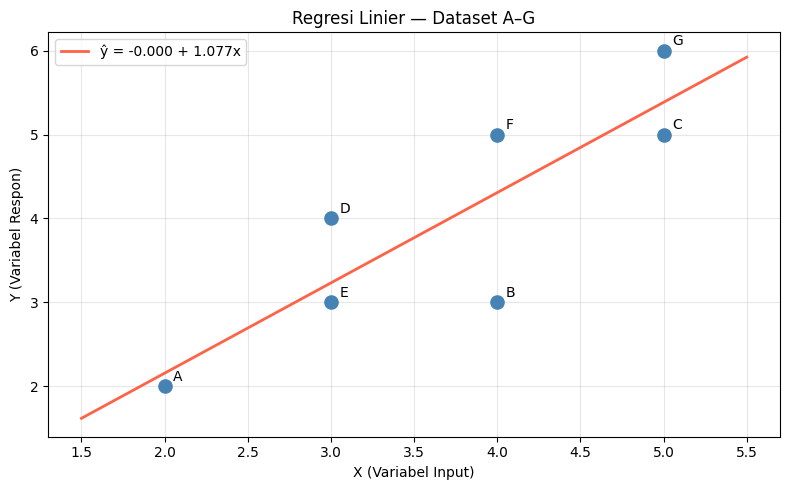

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# ── Dataset (7 titik A–G) ──────────────────────────────────
X = np.array([2, 4, 5, 3, 3, 4, 5], dtype=float).reshape(-1, 1)
Y = np.array([2, 3, 5, 4, 3, 5, 6], dtype=float)
labels = list("ABCDEFG")

# ── Latih model ────────────────────────────────────────────
model = LinearRegression()
model.fit(X, Y)

print(f"Intercept  b₀ : {model.intercept_:.4f}")
print(f"Koefisien  b₁ : {model.coef_[0]:.4f}")

# ── Prediksi & visualisasi ─────────────────────────────────
X_line = np.linspace(1.5, 5.5, 200).reshape(-1, 1)
Y_line = model.predict(X_line)

plt.figure(figsize=(8, 5))
plt.scatter(X, Y, color="steelblue", s=90, zorder=5)
for i, lbl in enumerate(labels):
    plt.annotate(lbl, (X[i, 0], Y[i]), textcoords="offset points",
                 xytext=(6, 4), fontsize=10)
plt.plot(X_line, Y_line, color="tomato", lw=2,
         label=f"ŷ = {model.intercept_:.3f} + {model.coef_[0]:.3f}x")
plt.xlabel("X (Variabel Input)")
plt.ylabel("Y (Variabel Respon)")
plt.title("Regresi Linier — Dataset A–G")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.2 Perhitungan OLS Analitik (dari Nol)

Implementasi langsung formula {eq}`eq-ols` tanpa library ML:

In [2]:
import numpy as np

# ── Data ───────────────────────────────────────────────────
X_raw = np.array([2, 4, 5, 3, 3, 4, 5], dtype=float)
Y     = np.array([2, 3, 5, 4, 3, 5, 6], dtype=float)
labels = list("ABCDEFG")

# ── Susun matriks X (tambah kolom 1 untuk intercept) ───────
X = np.column_stack([np.ones(len(X_raw)), X_raw])
print("Matriks X:\n", X)

# ── Hitung komponen OLS ────────────────────────────────────
XTX     = X.T @ X          # [[7, 26], [26, 104]]
XTX_inv = np.linalg.inv(XTX)
XTY     = X.T @ Y          # [28, 112]

# ── Koefisien b ────────────────────────────────────────────
b = XTX_inv @ XTY
print(f"\nb₀ (intercept) = {b[0]:.4f}")
print(f"b₁ (slope)     = {b[1]:.4f}")

# ── Prediksi & evaluasi ────────────────────────────────────
Y_hat  = X @ b
SS_res = np.sum((Y - Y_hat) ** 2)
SS_tot = np.sum((Y - Y.mean()) ** 2)
R2     = 1 - SS_res / SS_tot

print("\nPrediksi vs Aktual:")
for lbl, xi, yi, yh in zip(labels, X_raw, Y, Y_hat):
    print(f"  {lbl}: x={xi:.0f}  y={yi:.0f}  ŷ={yh:.3f}  e={yi-yh:+.3f}")

print(f"\nSS_res = {SS_res:.4f}")
print(f"SS_tot = {SS_tot:.4f}")
print(f"R²     = {R2:.4f}")

Matriks X:
 [[1. 2.]
 [1. 4.]
 [1. 5.]
 [1. 3.]
 [1. 3.]
 [1. 4.]
 [1. 5.]]

b₀ (intercept) = 0.0000
b₁ (slope)     = 1.0769

Prediksi vs Aktual:
  A: x=2  y=2  ŷ=2.154  e=-0.154
  B: x=4  y=3  ŷ=4.308  e=-1.308
  C: x=5  y=5  ŷ=5.385  e=-0.385
  D: x=3  y=4  ŷ=3.231  e=+0.769
  E: x=3  y=3  ŷ=3.231  e=-0.231
  F: x=4  y=5  ŷ=4.308  e=+0.692
  G: x=5  y=6  ŷ=5.385  e=+0.615

SS_res = 3.3846
SS_tot = 12.0000
R²     = 0.7179


### 7.3 Verifikasi Rumus Sxx / Sxy

In [3]:
import numpy as np

X_raw = np.array([2, 4, 5, 3, 3, 4, 5], dtype=float)
Y     = np.array([2, 3, 5, 4, 3, 5, 6], dtype=float)

x_bar = X_raw.mean()   # 3.7143
y_bar = Y.mean()       # 4.0

Sxx  = np.sum((X_raw - x_bar) ** 2)          # 7.4286
Sxy  = np.sum((X_raw - x_bar) * (Y - y_bar)) # 8.0

b1 = Sxy / Sxx
b0 = y_bar - b1 * x_bar

print(f"x̄    = {x_bar:.4f}")
print(f"ȳ    = {y_bar:.4f}")
print(f"Sxx  = {Sxx:.4f}")
print(f"Sxy  = {Sxy:.4f}")
print(f"b₁   = Sxy/Sxx = {b1:.4f}")
print(f"b₀   = ȳ - b₁x̄ = {b0:.4f}")
print(f"\nPersamaan: ŷ = {b0:.4f} + {b1:.4f}x")

x̄    = 3.7143
ȳ    = 4.0000
Sxx  = 7.4286
Sxy  = 8.0000
b₁   = Sxy/Sxx = 1.0769
b₀   = ȳ - b₁x̄ = 0.0000

Persamaan: ŷ = 0.0000 + 1.0769x


---

## 8. Visualisasi Interaktif di GeoGebra

Applet di bawah ini memuat langsung dari GeoGebra dan sudah berisi dataset A–G beserta garis regresi, residual, dan nilai $R^2$ yang dihitung secara otomatis. Kamu bisa **menggeser titik** untuk melihat bagaimana garis regresi berubah secara real-time.

```{raw} html
<div style="position: relative; width: 100%; padding-bottom: 0; margin: 1.5rem 0;">
  <iframe src="https://www.geogebra.org/classic/jrurjnhb?embed" width="800" height="600" allowfullscreen style="border: 1px solid #e4e4e4;border-radius: 4px;" frameborder="0"></iframe>
</div>
```

### Cara Membuat Applet Sendiri di GeoGebra Classic

Jika ingin membuat dari nol dengan data A–G, buka <https://www.geogebra.org/classic> lalu ketik perintah berikut **satu per satu** di **Input Bar** (baris paling bawah layar):

**① Input data:**

```text
X_data = {2, 4, 5, 3, 3, 4, 5}
Y_data = {2, 3, 5, 4, 3, 5, 6}
```

**② Buat 7 titik (A–G):**

```text
A = (2, 2)
B = (4, 3)
C = (5, 5)
D = (3, 4)
E = (3, 3)
F = (4, 5)
G = (5, 6)
```

**③ Fit garis regresi otomatis:**

```text
garis = FitLine({A, B, C, D, E, F, G})
```

**④ Hitung koefisien OLS manual (verifikasi):**

```text
x_bar = Mean(X_data)
y_bar = Mean(Y_data)
Sxx   = Sum(Zip((x - x_bar)^2, x, X_data))
Sxy   = Sum(Zip((x - x_bar)(y - y_bar), x, X_data, y, Y_data))
b1    = Sxy / Sxx
b0    = y_bar - b1 * x_bar
```

**⑤ Gambar residual (segmen vertikal tiap titik ke garis):**

```text
res_A = Segment(A, (x(A), b0 + b1 * x(A)))
res_B = Segment(B, (x(B), b0 + b1 * x(B)))
res_C = Segment(C, (x(C), b0 + b1 * x(C)))
res_D = Segment(D, (x(D), b0 + b1 * x(D)))
res_E = Segment(E, (x(E), b0 + b1 * x(E)))
res_F = Segment(F, (x(F), b0 + b1 * x(F)))
res_G = Segment(G, (x(G), b0 + b1 * x(G)))
```

**⑥ Hitung $R^2$:**

```text
Y_hat  = Map(b0 + b1 * x, X_data)
SS_res = Sum(Zip((y - yh)^2, y, Y_data, yh, Y_hat))
SS_tot = Sum(Zip((y - y_bar)^2, y, Y_data))
R2     = 1 - SS_res / SS_tot
```

> Hasil yang diharapkan: `b0 = 0`, `b1 ≈ 1.0769`, `R2 ≈ 0.718`

**⑦ Simpan dan embed ke Jupyter Book:**

Setelah selesai, klik **Share** → **Embed** di GeoGebra, lalu salin `material id` dari URL-nya (contoh: `jqbhrbmd`) dan gunakan template berikut di file `.md`:

````text
```{raw} html
<iframe
  src="https://www.geogebra.org/material/iframe/id/MATERIAL_ID/width/800/height/500/border/888888/sfsb/true/sdz/true"
  width="100%"
  height="500px"
  style="border: 1px solid #ccc; border-radius: 8px;"
  allowfullscreen>
</iframe>
```
````

Ganti `MATERIAL_ID` dengan ID applet milikmu.

---

## 9. Ringkasan Rumus

```{list-table} Kumpulan Rumus Penting
:header-rows: 1
:widths: 45 55

* - Rumus
  - Keterangan
* - $\hat{\mathbf{b}} = (X^T X)^{-1} X^T Y$
  - OLS estimator — rumus utama
* - $SS_{\text{res}} = \sum_{i=1}^N (\hat{y}_i - y_i)^2$
  - Sum of Squared Residuals (yang diminimalkan)
* - $R^2 = 1 - \dfrac{SS_{\text{res}}}{SS_{\text{tot}}}$
  - Koefisien determinasi (0–1, makin besar makin baik)
* - $b_1 = \dfrac{S_{xy}}{S_{xx}}$
  - Slope — regresi sederhana
* - $b_0 = \bar{y} - b_1 \bar{x}$
  - Intercept — regresi sederhana
* - $SS_{\text{tot}} = \sum (y_i - \bar{y})^2$
  - Total variabilitas data
```

**Hasil untuk dataset A–G ini:**

| Nilai | Hasil |
|-------|-------|
| $b_0$ | $0$ |
| $b_1$ | $\approx 1.0769$ |
| Persamaan | $\hat{y} = 1.077x$ |
| $R^2$ | $\approx 0.718$ |

---

:::{seealso}
Materi lanjutan yang berhubungan:

- **Ridge Regression** — OLS dengan regularisasi L2: $\hat{b} = (X^TX + \lambda I)^{-1}X^TY$
- **Lasso Regression** — regularisasi L1 (menghasilkan sparse coefficients)
- **Logistic Regression** — klasifikasi berbasis regresi linier
:::

*Referensi: Slide Linear Regression — Supervised Learning*